# CardioIA – Ir Além 2: Diagnóstico visual de ECG com rede neural (MLP + Keras)
**Autoria:** Marina Clara

**Objetivo:** classificar batimentos de ECG como **normal** ou **anormal** com um **MLP** (Perceptron Multicamadas).

**Dataset:** [Heartbeat (Kaggle)](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) – arquivos `ptbdb_normal.csv` e `ptbdb_abnormal.csv`.
Cada linha é **um batimento** (187 pontos de amplitude, valores entre 0 e 1) + a última coluna é o rótulo.

**Sobre "imagens":** o enunciado pede pré-processamento de *imagens* (redimensionar e tons de cinza). O dataset recomendado entrega o ECG como **sinal numérico**. Para cumprir o enunciado, **desenhamos cada sinal como uma imagem em tons de cinza 64×64** e treinamos o MLP nessas imagens. Assim há pré-processamento de imagem real (redimensionamento + escala de cinza + normalização).

**Pipeline:** CSV → sinal → imagem 64×64 → achatar (flatten) → MLP → acurácia.

## 1. Importações

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Sementes fixas para o resultado ser reprodutível.
np.random.seed(42)
tf.random.set_seed(42)

## 2. Baixando/carregando os dados
Opção A (automática): `kagglehub` (precisa de conta/credenciais do Kaggle configuradas).
Opção B (manual): baixe o ZIP no Kaggle, extraia e coloque `ptbdb_normal.csv` e `ptbdb_abnormal.csv` na pasta `data/`.

In [4]:
def localizar_dados():
    # Tenta a pasta local 'data/' primeiro (opção B).
    if os.path.exists("data/ptbdb_normal.csv"):
        return "data"
    # Senão, tenta baixar via kagglehub (opção A).
    import kagglehub
    return kagglehub.dataset_download("shayanfazeli/heartbeat")

pasta = localizar_dados()
normal   = pd.read_csv(os.path.join(pasta, "ptbdb_normal.csv"),   header=None)  # sem cabeçalho
anormal  = pd.read_csv(os.path.join(pasta, "ptbdb_abnormal.csv"), header=None)
print("Normais:", normal.shape, "| Anormais:", anormal.shape)

# Junta tudo: as 187 primeiras colunas são o sinal; a coluna 187 é o rótulo (0 normal, 1 anormal).
dados = pd.concat([normal, anormal], ignore_index=True)
sinais = dados.iloc[:, :187].values.astype("float32")
rotulos = dados.iloc[:, 187].values.astype("int32")
print("Distribuição:", np.bincount(rotulos), "(0 = normal, 1 = anormal)")

Normais: (4046, 188) | Anormais: (10506, 188)
Distribuição: [ 4046 10506] (0 = normal, 1 = anormal)


## 3. Pré-processamento: sinal → imagem em tons de cinza 64×64
Passos:
1. **Redimensionar**: os 187 pontos viram 64 colunas (interpolação linear).
2. **Tons de cinza**: imagem de 1 canal; fundo preto (0) e traço do ECG branco (255).
3. **Normalização**: dividir por 255 deixa os pixels em [0, 1], o que ajuda a rede a treinar.

In [5]:
TAM = 64  # lado da imagem (64x64)

def sinal_para_imagem(sinal, tam=TAM):
    """Desenha um sinal 1D como imagem em tons de cinza (tam x tam)."""
    # 1) Redimensiona o eixo X: 187 amostras -> 'tam' colunas
    x_antigo = np.linspace(0, 1, len(sinal))
    x_novo = np.linspace(0, 1, tam)
    y = np.interp(x_novo, x_antigo, sinal)

    # 2) Converte amplitude (0..1) em linha da imagem. Linha 0 é o TOPO, por isso (1 - y).
    linhas = np.clip(((1 - y) * (tam - 1)).round().astype(int), 0, tam - 1)

    img = np.zeros((tam, tam), dtype="float32")          # fundo preto
    for col in range(tam):
        img[linhas[col], col] = 1.0                       # pinta o ponto do sinal
        if col > 0:                                       # liga ao ponto anterior (traço contínuo)
            a, b = sorted((linhas[col - 1], linhas[col]))
            img[a:b + 1, col] = 1.0
    return img                                            # já em [0, 1] (normalizado)

# Gera todas as imagens: formato (n_amostras, 64, 64)
imagens = np.stack([sinal_para_imagem(s) for s in sinais])
print("Imagens:", imagens.shape)

Imagens: (14552, 64, 64)


### 3.1 Exemplos (e salvando alguns PNGs para o repositório)

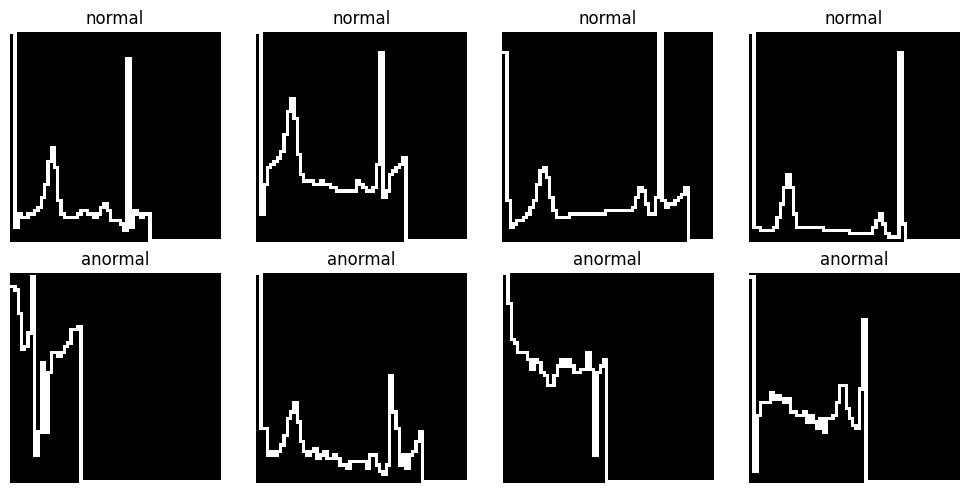

In [6]:
os.makedirs("exemplos", exist_ok=True)
fig, eixos = plt.subplots(2, 4, figsize=(10, 5))
for i, rotulo in enumerate([0, 1]):
    indices = np.where(rotulos == rotulo)[0][:4]
    for j, idx in enumerate(indices):
        eixos[i, j].imshow(imagens[idx], cmap="gray")
        eixos[i, j].set_title("normal" if rotulo == 0 else "anormal")
        eixos[i, j].axis("off")
        plt.imsave(f"exemplos/{'normal' if rotulo == 0 else 'anormal'}_{j+1}.png", imagens[idx], cmap="gray")
plt.tight_layout(); plt.show()

## 4. Divisão treino / validação / teste
- 70% treino, 15% validação (acompanha o treino e evita *overfitting*), 15% teste (nota final, nunca visto).
- `stratify` mantém a proporção normal/anormal em todos os conjuntos.

In [7]:
X_treino, X_temp, y_treino, y_temp = train_test_split(imagens, rotulos, test_size=0.30, random_state=42, stratify=rotulos)
X_val, X_teste, y_val, y_teste     = train_test_split(X_temp, y_temp,  test_size=0.50, random_state=42, stratify=y_temp)
print("Treino:", X_treino.shape, "| Validação:", X_val.shape, "| Teste:", X_teste.shape)

# O dataset é desbalanceado (mais anormais). class_weight faz a rede "dar mais atenção" à classe menor.
pesos = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_treino)
class_weight = {0: pesos[0], 1: pesos[1]}
print("Pesos das classes:", class_weight)

Treino: (10186, 64, 64) | Validação: (2183, 64, 64) | Teste: (2183, 64, 64)
Pesos das classes: {0: np.float64(1.7983757062146892), 1: np.float64(0.6925482730486809)}


## 5. Criando o MLP com Keras
Um MLP só aceita vetores, então a primeira camada **achata** (`Flatten`) a imagem 64×64 em 4096 números.
- `Dense(128, relu)` e `Dense(64, relu)`: camadas ocultas que aprendem padrões; `relu` = max(0, x), introduz não linearidade.
- `Dropout(0.3)`: "desliga" 30% dos neurônios a cada passo no treino, reduzindo overfitting.
- `Dense(1, sigmoid)`: saída entre 0 e 1 = probabilidade de ser **anormal**.
- `binary_crossentropy`: função de perda para classificação binária; `adam`: otimizador.

In [8]:
modelo = keras.Sequential([
    layers.Input(shape=(TAM, TAM)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
modelo.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,737 (2.03 MB)

 Trainable params: 532,737 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento
`EarlyStopping` para o treino quando a perda de validação para de melhorar e restaura os melhores pesos.

In [9]:
parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
historico = modelo.fit(
    X_treino, y_treino,
    validation_data=(X_val, y_val),
    epochs=40, batch_size=64,
    class_weight=class_weight,
    callbacks=[parada], verbose=2,
)

Epoch 1/40
160/160 - 3s - 20ms/step - accuracy: 0.8225 - loss: 0.3895 - val_accuracy: 0.8910 - val_loss: 0.2552
Epoch 2/40
160/160 - 2s - 15ms/step - accuracy: 0.9109 - loss: 0.2134 - val_accuracy: 0.9276 - val_loss: 0.1877
Epoch 3/40
160/160 - 2s - 10ms/step - accuracy: 0.9484 - loss: 0.1391 - val_accuracy: 0.9455 - val_loss: 0.1517
Epoch 4/40
160/160 - 2s - 10ms/step - accuracy: 0.9643 - loss: 0.0961 - val_accuracy: 0.9459 - val_loss: 0.1505
Epoch 5/40
160/160 - 2s - 9ms/step - accuracy: 0.9730 - loss: 0.0737 - val_accuracy: 0.9492 - val_loss: 0.1453
Epoch 6/40
160/160 - 2s - 10ms/step - accuracy: 0.9776 - loss: 0.0622 - val_accuracy: 0.9579 - val_loss: 0.1379
Epoch 7/40
160/160 - 2s - 10ms/step - accuracy: 0.9822 - loss: 0.0477 - val_accuracy: 0.9382 - val_loss: 0.1997
Epoch 8/40
160/160 - 3s - 18ms/step - accuracy: 0.9849 - loss: 0.0396 - val_accuracy: 0.9510 - val_loss: 0.1829
Epoch 9/40
160/160 - 2s - 15ms/step - accuracy: 0.9874 - loss: 0.0334 - val_accuracy: 0.9510 - val_loss: 

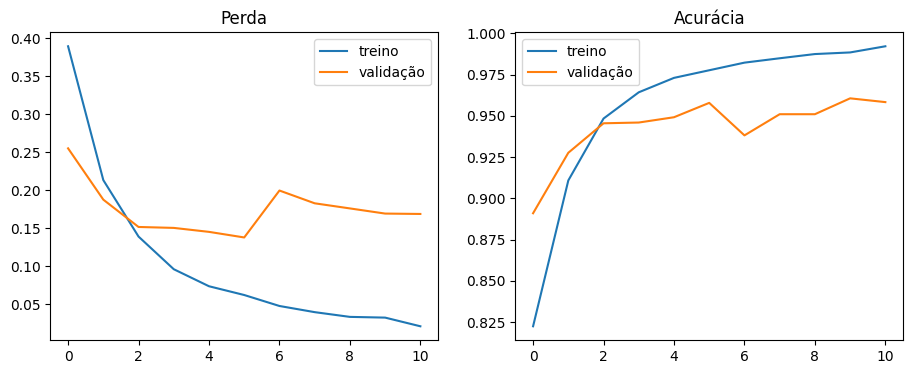

In [10]:
# Curvas de aprendizado: se treino sobe e validação desce/estagna, há overfitting.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(historico.history["loss"], label="treino");     a1.plot(historico.history["val_loss"], label="validação"); a1.set_title("Perda"); a1.legend()
a2.plot(historico.history["accuracy"], label="treino"); a2.plot(historico.history["val_accuracy"], label="validação"); a2.set_title("Acurácia"); a2.legend()
plt.show()

## 7. Avaliação no conjunto de teste

Acurácia no teste: 96.01% | Perda: 0.1118
              precision    recall  f1-score   support

      normal       0.91      0.95      0.93       607
     anormal       0.98      0.97      0.97      1576

    accuracy                           0.96      2183
   macro avg       0.95      0.96      0.95      2183
weighted avg       0.96      0.96      0.96      2183



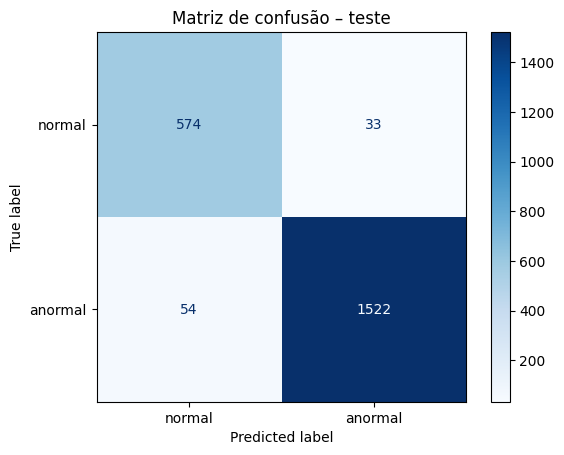

In [11]:
perda, acuracia = modelo.evaluate(X_teste, y_teste, verbose=0)
print(f"Acurácia no teste: {acuracia:.2%} | Perda: {perda:.4f}")

# Probabilidade > 0.5 => anormal (1)
previsoes = (modelo.predict(X_teste, verbose=0) > 0.5).astype(int).ravel()
print(classification_report(y_teste, previsoes, target_names=["normal", "anormal"]))

ConfusionMatrixDisplay(confusion_matrix(y_teste, previsoes), display_labels=["normal", "anormal"]).plot(cmap="Blues")
plt.title("Matriz de confusão – teste"); plt.show()

## 8. Resultados e discussão
No teste, o MLP chegou a 96,01% de acurácia. A classe anormal teve recall de 0,97 (54 falsos negativos em 1576 batimentos) e a classe normal teve recall de 0,95 (33 falsos positivos em 607).

- **Acurácia:** como a base tem mais batimentos anormais que normais, só a acurácia pode enganar. Por isso olhamos também o recall da classe anormal (quantos casos anormais foram detectados). Em triagem, deixar passar um caso anormal (falso negativo) é o erro mais grave.
- **Limitações:** o MLP não considera a vizinhança dos pixels (uma CNN seria mais adequada) e o dataset vem de poucos pacientes e equipamentos, então pode não generalizar.
- **Uso:** é um apoio à decisão e não substitui o médico.
